# Assignment 2 Notebook 03

## Aim: Implement Data Storage and the Database Schema

In [1]:
# Install required packages from requirements.txt
import sys
import subprocess
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))
requirements_path = PROJECT_ROOT / "requirements.txt"

if requirements_path.exists():
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-r",
        str(requirements_path)
    ])
    print("Packages installed from:", requirements_path)
else:
    raise FileNotFoundError(f"requirements.txt not found at: {requirements_path}")

Packages installed from: C:\Users\The_Won\Comp5339A2\requirements.txt


In [2]:
# Import libraries and set up folders

import duckdb
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from datetime import datetime
import warnings

warnings.filterwarnings("ignore")

print("DuckDB version:", duckdb.__version__)
print("Pandas version:", pd.__version__)


DuckDB version: 1.5.2
Pandas version: 2.3.3


In [3]:
# Project folders
PROJECT_ROOT = Path.cwd().parent

RAW_DIR = PROJECT_ROOT / "data" / "raw" / "openelectricity"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
A1_DIR = PROJECT_ROOT / "data" / "raw" / "A1"
DB_DIR = PROJECT_ROOT / "data" / "database"
OUTPUT_DIR = PROJECT_ROOT / "output" / "figures"

for folder in [RAW_DIR, PROCESSED_DIR, A1_DIR, DB_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Input files
# Assignment 1 geocoded dataset
A1_PATH = A1_DIR / "final_dataset_for_storage.csv"

# Assignment 2 5-minute facility-level stream dataset from 01_data_retrieval_cleaning_final.ipynb
STREAM_PATH = PROCESSED_DIR / "facility_power_emissions_5min_may2026.csv"

# Database output
DB_PATH = DB_DIR / "electricity_project.duckdb"

print("Project root:", PROJECT_ROOT)
print("Assignment 1 data:", A1_PATH)
print("Assignment 2 stream data:", STREAM_PATH)
print("Database path:", DB_PATH)
print("Schema figure folder:", OUTPUT_DIR)


Project root: C:\Users\The_Won\Comp5339A2
Assignment 1 data: C:\Users\The_Won\Comp5339A2\data\raw\A1\final_dataset_for_storage.csv
Assignment 2 stream data: C:\Users\The_Won\Comp5339A2\data\processed\facility_power_emissions_5min_may2026.csv
Database path: C:\Users\The_Won\Comp5339A2\data\database\electricity_project.duckdb
Schema figure folder: C:\Users\The_Won\Comp5339A2\output\figures


In [4]:
# Helper functions

def standardise_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Convert column names to snake_case-style names used across the project."""
    df = df.copy()
    df.columns = (
        df.columns.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(" ", "_", regex=False)
        .str.replace("-", "_", regex=False)
        .str.replace("(", "", regex=False)
        .str.replace(")", "", regex=False)
        .str.replace(".", "", regex=False)
    )
    return df


def require_columns(df: pd.DataFrame, required_cols: list, df_name: str) -> None:
    """Raise a clear error if required columns are missing."""
    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{df_name} is missing required columns: {missing}")


def clean_text_key(series: pd.Series) -> pd.Series:
    """Create a stable text key for matching facility names and states."""
    return (
        series.astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
    )


In [5]:
# Load Assignment 1 geocoded facility data

if not A1_PATH.exists():
    raise FileNotFoundError(
        f"Assignment 1 file not found: {A1_PATH}"
        "Please place final_dataset_for_storage.csv in data/raw/A1/."
    )

a1_df = pd.read_csv(A1_PATH)
a1_df = standardise_columns(a1_df)

print("A1 dataset shape:", a1_df.shape)
display(a1_df.head())
print(a1_df.columns.tolist())


A1 dataset shape: (3298, 16)


,reporting_entity,facility_name,state,year,electricity_production_mwh,total_emissions_t_co2_e,emission_intensity_t_co2_e_mwh,population,population_density,median_age,installed_capacity_mw,latitude,longitude,facility_type,matched_query,geo_match_method
0,Acciona Energy Oceania Pty. Ltd.,Cathedral Rocks Wind Farm,SA,2019,175634.0,252.0,0.001435,1767395.0,1.8,40.1,3.091,-30.534367,135.630121,wind_farm,"SA, Australia",state_fallback
1,Acciona Energy Oceania Pty. Ltd.,Gunning Wind Farm,NSW,2019,164669.0,239.0,0.001451,8046748.0,10.0,37.7,21.637,-31.875984,147.286949,wind_farm,"NSW, Australia",state_fallback
2,Acciona Energy Oceania Pty. Ltd.,Mt Gellibrand Wind Farm,VIC,2019,234630.0,900.0,0.003836,6537305.0,28.7,36.9,579.132,-36.598610,144.678005,wind_farm,"VIC, Australia",state_fallback
3,Acciona Energy Oceania Pty. Ltd.,Waubra Wind Farm,VIC,2019,628100.0,993.0,0.001581,6537305.0,28.7,36.9,579.132,-37.352857,143.631327,wind_farm,"Waubra Wind Farm, VIC, Australia",original_name
4,AGL Energy Limited,Banimboola Hydro,VIC,2019,42574.0,21.0,0.000493,6537305.0,28.7,36.9,579.132,-36.598610,144.678005,hydro,"VIC, Australia",state_fallback


['reporting_entity', 'facility_name', 'state', 'year', 'electricity_production_mwh', 'total_emissions_t_co2_e', 'emission_intensity_t_co2_e_mwh', 'population', 'population_density', 'median_age', 'installed_capacity_mw', 'latitude', 'longitude', 'facility_type', 'matched_query', 'geo_match_method']


In [6]:
# Required columns from Assignment 1
required_a1_cols = [
    "facility_name",
    "reporting_entity",
    "state",
    "year",
    "electricity_production_mwh",
    "total_emissions_t_co2_e",
    "emission_intensity_t_co2_e_mwh",
    "population",
    "population_density",
    "median_age",
    "installed_capacity_mw",
    "latitude",
    "longitude"
]

require_columns(a1_df, required_a1_cols, "Assignment 1 dataset")

# Optional columns from the geocoding stage
if "matched_query" not in a1_df.columns:
    a1_df["matched_query"] = pd.NA

if "facility_type" not in a1_df.columns:
    a1_df["facility_type"] = pd.NA

if "geo_match_method" not in a1_df.columns:
    a1_df["geo_match_method"] = pd.NA

print("A1 required columns checked successfully.")


A1 required columns checked successfully.


In [7]:
# Load Assignment 2 5-minute streaming data

if not STREAM_PATH.exists():
    raise FileNotFoundError(
        f"Streaming file not found: {STREAM_PATH}"
        "Please run 01_data_retrieval_cleaning_final.ipynb first."
    )

stream_df = pd.read_csv(STREAM_PATH)
stream_df = standardise_columns(stream_df)

print("Stream dataset shape:", stream_df.shape)
display(stream_df.head())
print(stream_df.columns.tolist())


Stream dataset shape: (710406, 19)


,timestamp,facility_code,facility_name,a1_facility_name,a1_match_score,state,network_region,facility_type,latitude,longitude,latitude_api,longitude_api,latitude_a1,longitude_a1,power_mw,emissions_t_co2e,registered_capacity_mw,installed_capacity_mw_a1,reporting_entity
0,2026-05-01 00:00:00+10:00,ADP,Adelaide Desalination,NaN,0.454545,SA,SA1,"battery, battery_charging, battery_discharging...",-35.100751,138.483357,-35.100751,138.483357,NaN,NaN,0.0,0.0,49.69,NaN,NaN
1,2026-05-01 00:00:00+10:00,AGLHAL,Hallett,Hallett Power Station,1.000000,SA,SA1,gas_ocgt,-33.348616,138.751924,-33.349528,138.751607,-33.348616,138.751924,0.0,0.0,217.00,3.091,EnergyAustralia Holdings Limited
2,2026-05-01 00:00:00+10:00,AGLSOM,Somerton,Somerton Power Station,1.000000,VIC,VIC1,gas_ocgt,-37.631601,144.952562,-37.631692,144.952802,-37.631601,144.952562,0.0,0.0,170.00,579.132,AGL Energy Limited
3,2026-05-01 00:00:00+10:00,ALDGASF,Aldoga,NaN,0.533333,QLD,QLD1,solar_utility,-23.839544,151.084900,-23.839544,151.084900,NaN,NaN,0.0,0.0,535.21,NaN,NaN
4,2026-05-01 00:00:00+10:00,ANGASTON,Angaston,Angaston Power Station,1.000000,SA,SA1,distillate,-34.503393,139.024577,-34.503389,139.024580,-34.503393,139.024577,0.0,0.0,50.00,3.091,Snowy Hydro Limited


['timestamp', 'facility_code', 'facility_name', 'a1_facility_name', 'a1_match_score', 'state', 'network_region', 'facility_type', 'latitude', 'longitude', 'latitude_api', 'longitude_api', 'latitude_a1', 'longitude_a1', 'power_mw', 'emissions_t_co2e', 'registered_capacity_mw', 'installed_capacity_mw_a1', 'reporting_entity']


In [8]:
# Harmonise possible column names from different retrieval versions
rename_candidates = {
    "power": "power_mw",
    "generated_power_mw": "power_mw",
    "generation_mw": "power_mw",
    "emissions": "emissions_t_co2e",
    "co2_emissions": "emissions_t_co2e",
    "emission_t_co2e": "emissions_t_co2e",
    "facility": "facility_name",
    "name": "facility_name"
}

for old, new in rename_candidates.items():
    if old in stream_df.columns and new not in stream_df.columns:
        stream_df = stream_df.rename(columns={old: new})

required_stream_cols = ["timestamp", "facility_name", "state", "power_mw", "emissions_t_co2e"]
require_columns(stream_df, required_stream_cols, "Assignment 2 stream dataset")

stream_df["timestamp"] = pd.to_datetime(stream_df["timestamp"], errors="coerce")
stream_df["power_mw"] = pd.to_numeric(stream_df["power_mw"], errors="coerce")
stream_df["emissions_t_co2e"] = pd.to_numeric(stream_df["emissions_t_co2e"], errors="coerce")

# Optional fields used by dashboard/report
if "facility_type" not in stream_df.columns:
    stream_df["facility_type"] = pd.NA

stream_df = (
    stream_df
    .dropna(subset=["timestamp", "facility_name", "state"])
    .sort_values(["timestamp", "facility_name", "state"])
    .reset_index(drop=True)
)

print("Cleaned stream dataset shape:", stream_df.shape)
display(stream_df.head())


Cleaned stream dataset shape: (710406, 19)


,timestamp,facility_code,facility_name,a1_facility_name,a1_match_score,state,network_region,facility_type,latitude,longitude,latitude_api,longitude_api,latitude_a1,longitude_a1,power_mw,emissions_t_co2e,registered_capacity_mw,installed_capacity_mw_a1,reporting_entity
0,2026-05-01 00:00:00+10:00,ADP,Adelaide Desalination,NaN,0.454545,SA,SA1,"battery, battery_charging, battery_discharging...",-35.100751,138.483357,-35.100751,138.483357,NaN,NaN,0.0,0.0,49.69,NaN,NaN
1,2026-05-01 00:00:00+10:00,ALDGASF,Aldoga,NaN,0.533333,QLD,QLD1,solar_utility,-23.839544,151.084900,-23.839544,151.084900,NaN,NaN,0.0,0.0,535.21,NaN,NaN
2,2026-05-01 00:00:00+10:00,ANGASTON,Angaston,Angaston Power Station,1.000000,SA,SA1,distillate,-34.503393,139.024577,-34.503389,139.024580,-34.503393,139.024577,0.0,0.0,50.00,3.091,Snowy Hydro Limited
3,2026-05-01 00:00:00+10:00,ARWF,Ararat,NaN,0.500000,VIC,VIC1,wind,-37.263393,143.082116,-37.263393,143.082116,NaN,NaN,99.5,0.0,241.59,NaN,NaN
4,2026-05-01 00:00:00+10:00,AVLSF,Avonlie,Avonlie Solar Farm,1.000000,NSW,NSW1,solar_utility,-31.875984,147.286949,-34.913826,146.590545,-31.875984,147.286949,0.0,0.0,254.10,21.637,IBERDROLA AUSTRALIA LIMITED


In [9]:
# Build Assignment 1 relational tables
# Table 1: facilities

facility_cols = [
    "facility_name",
    "reporting_entity",
    "state",
    "facility_type",
    "installed_capacity_mw",
    "matched_query",
    "geo_match_method",
    "latitude",
    "longitude"
]

facilities_df = (
    a1_df[facility_cols]
    .drop_duplicates(subset=["facility_name", "state"])
    .reset_index(drop=True)
)

facilities_df["facility_id"] = facilities_df.index + 1

facilities_df = facilities_df[
    [
        "facility_id",
        "facility_name",
        "reporting_entity",
        "state",
        "facility_type",
        "installed_capacity_mw",
        "matched_query",
        "geo_match_method",
        "latitude",
        "longitude"
    ]
]

print("facilities_df shape:", facilities_df.shape)
display(facilities_df.head())


facilities_df shape: (735, 10)


,facility_id,facility_name,reporting_entity,state,facility_type,installed_capacity_mw,matched_query,geo_match_method,latitude,longitude
0,1,Cathedral Rocks Wind Farm,Acciona Energy Oceania Pty. Ltd.,SA,wind_farm,3.091,"SA, Australia",state_fallback,-30.534367,135.630121
1,2,Gunning Wind Farm,Acciona Energy Oceania Pty. Ltd.,NSW,wind_farm,21.637,"NSW, Australia",state_fallback,-31.875984,147.286949
2,3,Mt Gellibrand Wind Farm,Acciona Energy Oceania Pty. Ltd.,VIC,wind_farm,579.132,"VIC, Australia",state_fallback,-36.598610,144.678005
3,4,Waubra Wind Farm,Acciona Energy Oceania Pty. Ltd.,VIC,wind_farm,579.132,"Waubra Wind Farm, VIC, Australia",original_name,-37.352857,143.631327
4,5,Banimboola Hydro,AGL Energy Limited,VIC,hydro,579.132,"VIC, Australia",state_fallback,-36.598610,144.678005


In [10]:
# Merge facility_id back to Assignment 1 data
facility_key_cols = ["facility_name", "state"]

a1_with_id = a1_df.merge(
    facilities_df[["facility_id", "facility_name", "state"]],
    on=facility_key_cols,
    how="left"
)

# Table 2: annual facility metrics
facility_year_metrics_df = (
    a1_with_id[
        [
            "facility_id",
            "year",
            "electricity_production_mwh",
            "total_emissions_t_co2_e",
            "emission_intensity_t_co2_e_mwh"
        ]
    ]
    .dropna(subset=["facility_id", "year"])
    .drop_duplicates(subset=["facility_id", "year"])
    .reset_index(drop=True)
)

facility_year_metrics_df["facility_id"] = facility_year_metrics_df["facility_id"].astype(int)
facility_year_metrics_df["year"] = facility_year_metrics_df["year"].astype(int)

print("facility_year_metrics_df shape:", facility_year_metrics_df.shape)
display(facility_year_metrics_df.head())


facility_year_metrics_df shape: (3215, 5)


,facility_id,year,electricity_production_mwh,total_emissions_t_co2_e,emission_intensity_t_co2_e_mwh
0,1,2019,175634.0,252.0,0.001435
1,2,2019,164669.0,239.0,0.001451
2,3,2019,234630.0,900.0,0.003836
3,4,2019,628100.0,993.0,0.001581
4,5,2019,42574.0,21.0,0.000493


In [11]:
# Table 3: state-year demographic statistics
state_year_stats_df = (
    a1_df[
        [
            "state",
            "year",
            "population",
            "population_density",
            "median_age"
        ]
    ]
    .dropna(subset=["state", "year"])
    .drop_duplicates(subset=["state", "year"])
    .reset_index(drop=True)
)

state_year_stats_df["year"] = state_year_stats_df["year"].astype(int)

print("state_year_stats_df shape:", state_year_stats_df.shape)
display(state_year_stats_df.head())


state_year_stats_df shape: (48, 5)


,state,year,population,population_density,median_age
0,SA,2019,1767395.0,1.8,40.1
1,NSW,2019,8046748.0,10.0,37.7
2,VIC,2019,6537305.0,28.7,36.9
3,TAS,2019,547841.0,8.1,41.7
4,QLD,2019,5088847.0,2.9,37.6


In [12]:
# Link Assignment 2 stream records to Assignment 1 facilities

stream_match = stream_df.copy()
facilities_match = facilities_df.copy()

if "a1_facility_name" in stream_match.columns:
    stream_match["match_facility_name"] = stream_match["a1_facility_name"].fillna(stream_match["facility_name"])
else:
    stream_match["match_facility_name"] = stream_match["facility_name"]

stream_match["facility_name_key"] = clean_text_key(stream_match["match_facility_name"])
stream_match["state_key"] = clean_text_key(stream_match["state"])

facilities_match["facility_name_key"] = clean_text_key(facilities_match["facility_name"])
facilities_match["state_key"] = clean_text_key(facilities_match["state"])

stream_with_facility_id = stream_match.merge(
    facilities_match[["facility_id", "facility_name_key", "state_key", "latitude", "longitude"]],
    on=["facility_name_key", "state_key"],
    how="left"
)

matched_count = stream_with_facility_id["facility_id"].notna().sum()
match_rate = matched_count / len(stream_with_facility_id) if len(stream_with_facility_id) else 0

print(f"Matched stream records: {matched_count:,} / {len(stream_with_facility_id):,}")
print(f"Match rate: {match_rate:.2%}")

unmatched_stream = (
    stream_with_facility_id[stream_with_facility_id["facility_id"].isna()]
    [["facility_name", "state"]]
    .drop_duplicates()
    .sort_values(["state", "facility_name"])
)

print("Unique unmatched facilities:", len(unmatched_stream))
display(unmatched_stream.head(20))


Matched stream records: 419,324 / 710,406
Match rate: 59.03%
Unique unmatched facilities: 141


,facility_name,state
19,Biala,NSW
20,Blowering,NSW
66,Coleambally,NSW
72,Condong,NSW
79,Culcairn,NSW
102,Flyers Creek,NSW
109,Glenellen,NSW
120,Griffith,NSW
125,Guthega,NSW
141,Hume,NSW


In [13]:
# Keep only stream records that can be linked to a facility_id
# This protects the foreign key relationship in the database.
stream_linked_df = (
    stream_with_facility_id
    .dropna(subset=["facility_id"])
    .copy()
)

stream_linked_df["facility_id"] = stream_linked_df["facility_id"].astype(int)
stream_linked_df["record_id"] = range(1, len(stream_linked_df) + 1)
stream_linked_df["received_at"] = pd.Timestamp.now()

facility_stream_records_df = stream_linked_df[
    [
        "record_id",
        "facility_id",
        "timestamp",
        "power_mw",
        "emissions_t_co2e",
        "received_at"
    ]
].copy()

# Remove duplicate records for the same facility and timestamp, keeping the last value.
facility_stream_records_df = (
    facility_stream_records_df
    .sort_values(["timestamp", "facility_id", "record_id"])
    .drop_duplicates(subset=["facility_id", "timestamp"], keep="last")
    .reset_index(drop=True)
)
facility_stream_records_df["record_id"] = range(1, len(facility_stream_records_df) + 1)

print("facility_stream_records_df shape:", facility_stream_records_df.shape)
display(facility_stream_records_df.head())


facility_stream_records_df shape: (354812, 6)


,record_id,facility_id,timestamp,power_mw,emissions_t_co2e,received_at
0,1,1,2026-05-01 00:00:00+10:00,56.1000,0.0,2026-05-29 00:47:43.619987
1,2,2,2026-05-01 00:00:00+10:00,17.7867,0.0,2026-05-29 00:47:43.619987
2,3,3,2026-05-01 00:00:00+10:00,80.2713,0.0,2026-05-29 00:47:43.619987
3,4,4,2026-05-01 00:00:00+10:00,137.8579,0.0,2026-05-29 00:47:43.619987
4,5,6,2026-05-01 00:00:00+10:00,-0.3430,0.0,2026-05-29 00:47:43.619987


In [14]:
# 7.Create DuckDB database and tables

con = duckdb.connect(str(DB_PATH))
print("Connected to DuckDB:", DB_PATH)

# Load DuckDB spatial extension for geometry support.
# If your environment does not allow INSTALL, comment out INSTALL and keep LOAD if already installed.
try:
    con.execute("INSTALL spatial;")
    con.execute("LOAD spatial;")
    print("Spatial extension loaded successfully.")
except Exception as e:
    print("Spatial extension could not be loaded. Geometry column will be skipped if needed.")
    print("Error message:", e)


Connected to DuckDB: C:\Users\The_Won\Comp5339A2\data\database\electricity_project.duckdb
Spatial extension loaded successfully.


In [15]:
# Drop child tables first because of foreign key dependencies.
con.execute("DROP TABLE IF EXISTS facility_stream_records")
con.execute("DROP TABLE IF EXISTS facility_year_metrics")
con.execute("DROP TABLE IF EXISTS state_year_stats")
con.execute("DROP TABLE IF EXISTS facilities")

# Assignment 1 table 1: static facility information
con.execute("""
CREATE TABLE facilities (
    facility_id INTEGER PRIMARY KEY,
    facility_name VARCHAR NOT NULL,
    reporting_entity VARCHAR,
    state VARCHAR NOT NULL,
    facility_type VARCHAR,
    installed_capacity_mw DOUBLE,
    matched_query VARCHAR,
    geo_match_method VARCHAR,
    latitude DOUBLE,
    longitude DOUBLE,
    geom GEOMETRY
)
""")

# Assignment 1 table 2: annual facility-level metrics
con.execute("""
CREATE TABLE facility_year_metrics (
    facility_id INTEGER NOT NULL,
    year INTEGER NOT NULL,
    electricity_production_mwh DOUBLE,
    total_emissions_t_co2_e DOUBLE,
    emission_intensity_t_co2_e_mwh DOUBLE,
    PRIMARY KEY (facility_id, year),
    FOREIGN KEY (facility_id) REFERENCES facilities(facility_id)
)
""")

# Assignment 1 table 3: state-level annual demographic data
con.execute("""
CREATE TABLE state_year_stats (
    state VARCHAR NOT NULL,
    year INTEGER NOT NULL,
    population DOUBLE,
    population_density DOUBLE,
    median_age DOUBLE,
    PRIMARY KEY (state, year)
)
""")

# Assignment 2 table 4: 5-minute facility-level streaming records
con.execute("""
CREATE TABLE facility_stream_records (
    record_id INTEGER PRIMARY KEY,
    facility_id INTEGER NOT NULL,
    timestamp TIMESTAMP NOT NULL,
    power_mw DOUBLE,
    emissions_t_co2e DOUBLE,
    received_at TIMESTAMP,
    FOREIGN KEY (facility_id) REFERENCES facilities(facility_id)
)
""")

print("Database schema created successfully.")


Database schema created successfully.


In [16]:
# Insert data into the database

# Insert facilities, including spatial geometry from longitude and latitude.
con.register("facilities_df_view", facilities_df)

con.execute("""
INSERT INTO facilities (
    facility_id,
    facility_name,
    reporting_entity,
    state,
    facility_type,
    installed_capacity_mw,
    matched_query,
    geo_match_method,
    latitude,
    longitude,
    geom
)
SELECT
    facility_id,
    facility_name,
    reporting_entity,
    state,
    facility_type,
    installed_capacity_mw,
    matched_query,
    geo_match_method,
    latitude,
    longitude,
    CASE
        WHEN longitude IS NOT NULL AND latitude IS NOT NULL
        THEN ST_Point(longitude, latitude)
        ELSE NULL
    END AS geom
FROM facilities_df_view
""")

print("Inserted facilities:", con.execute("SELECT COUNT(*) FROM facilities").fetchone()[0])


Inserted facilities: 735


In [17]:
# Insert Assignment 1 annual tables
con.register("facility_year_metrics_df_view", facility_year_metrics_df)
con.register("state_year_stats_df_view", state_year_stats_df)

con.execute("INSERT INTO facility_year_metrics SELECT * FROM facility_year_metrics_df_view")
con.execute("INSERT INTO state_year_stats SELECT * FROM state_year_stats_df_view")

print("Inserted facility_year_metrics:", con.execute("SELECT COUNT(*) FROM facility_year_metrics").fetchone()[0])
print("Inserted state_year_stats:", con.execute("SELECT COUNT(*) FROM state_year_stats").fetchone()[0])


Inserted facility_year_metrics: 3215
Inserted state_year_stats: 48


In [18]:
# Insert Assignment 2 streaming table
con.register("facility_stream_records_df_view", facility_stream_records_df)
con.execute("INSERT INTO facility_stream_records SELECT * FROM facility_stream_records_df_view")

print("Inserted facility_stream_records:", con.execute("SELECT COUNT(*) FROM facility_stream_records").fetchone()[0])


Inserted facility_stream_records: 354812


In [19]:
# Clean up temporary registered views
for view_name in [
    "facilities_df_view",
    "facility_year_metrics_df_view",
    "state_year_stats_df_view",
    "facility_stream_records_df_view"
]:
    try:
        con.unregister(view_name)
    except Exception:
        pass

print("Temporary views unregistered.")


Temporary views unregistered.


In [20]:
# Validate database tables

print("Database tables:")
display(con.execute("SHOW TABLES").fetchdf())


Database tables:


,name
0,facilities
1,facility_stream_records
2,facility_year_metrics
3,latest_facility_stream_view
4,state_year_stats


In [21]:
table_counts = []
for table in ["facilities", "facility_year_metrics", "state_year_stats", "facility_stream_records"]:
    count = con.execute(f"SELECT COUNT(*) FROM {table}").fetchone()[0]
    table_counts.append({"table": table, "row_count": count})

counts_df = pd.DataFrame(table_counts)
display(counts_df)


,table,row_count
0,facilities,735
1,facility_year_metrics,3215
2,state_year_stats,48
3,facility_stream_records,354812


In [22]:
print("Facilities preview:")
display(con.execute("SELECT * EXCLUDE (geom) FROM facilities LIMIT 5").fetchdf())

print("Streaming records preview:")
display(con.execute("SELECT * FROM facility_stream_records LIMIT 5").fetchdf())


Facilities preview:


,facility_id,facility_name,reporting_entity,state,facility_type,installed_capacity_mw,matched_query,geo_match_method,latitude,longitude
0,1,Cathedral Rocks Wind Farm,Acciona Energy Oceania Pty. Ltd.,SA,wind_farm,3.091,"SA, Australia",state_fallback,-30.534367,135.630121
1,2,Gunning Wind Farm,Acciona Energy Oceania Pty. Ltd.,NSW,wind_farm,21.637,"NSW, Australia",state_fallback,-31.875984,147.286949
2,3,Mt Gellibrand Wind Farm,Acciona Energy Oceania Pty. Ltd.,VIC,wind_farm,579.132,"VIC, Australia",state_fallback,-36.598610,144.678005
3,4,Waubra Wind Farm,Acciona Energy Oceania Pty. Ltd.,VIC,wind_farm,579.132,"Waubra Wind Farm, VIC, Australia",original_name,-37.352857,143.631327
4,5,Banimboola Hydro,AGL Energy Limited,VIC,hydro,579.132,"VIC, Australia",state_fallback,-36.598610,144.678005


Streaming records preview:


,record_id,facility_id,timestamp,power_mw,emissions_t_co2e,received_at
0,1,1,2026-05-01,56.1000,0.0,2026-05-29 00:47:43.619987
1,2,2,2026-05-01,17.7867,0.0,2026-05-29 00:47:43.619987
2,3,3,2026-05-01,80.2713,0.0,2026-05-29 00:47:43.619987
3,4,4,2026-05-01,137.8579,0.0,2026-05-29 00:47:43.619987
4,5,6,2026-05-01,-0.3430,0.0,2026-05-29 00:47:43.619987


In [23]:
# Validate the relationship between streaming data and facility location.
stream_location_query = """
SELECT
    f.facility_name,
    f.state,
    f.facility_type,
    f.latitude,
    f.longitude,
    s.timestamp,
    s.power_mw,
    s.emissions_t_co2e
FROM facility_stream_records s
JOIN facilities f
    ON s.facility_id = f.facility_id
WHERE f.latitude IS NOT NULL
  AND f.longitude IS NOT NULL
ORDER BY s.timestamp, f.facility_name
LIMIT 10
"""

stream_location_sample = con.execute(stream_location_query).fetchdf()
display(stream_location_sample)


,facility_name,state,facility_type,latitude,longitude,timestamp,power_mw,emissions_t_co2e
0,Adani Rugby Run Solar Farm,QLD,solar,-22.164678,144.584490,2026-05-01,0.0000,0.0
1,Angaston Power Station,SA,power_station,-34.503393,139.024577,2026-05-01,0.0000,0.0
2,Avonlie Solar Farm,NSW,solar,-31.875984,147.286949,2026-05-01,0.0000,0.0
3,BULGANA GREEN POWER HUB,VIC,other,-37.038163,142.983558,2026-05-01,122.6094,0.0
4,Bairnsdale Power Station,VIC,power_station,-37.842918,147.563855,2026-05-01,0.0000,0.0
5,Bango Wind Farm,NSW,wind_farm,-31.875984,147.286949,2026-05-01,28.2952,0.0
6,Bannerton Solar Farm,VIC,solar,-36.598610,144.678005,2026-05-01,0.0000,0.0
7,Barcaldine Power Station Facility,QLD,generic_facility,-22.164678,144.584490,2026-05-01,0.2000,0.0
8,Barker Inlet Power Station,SA,power_station,-34.803855,138.523809,2026-05-01,0.0000,0.0
9,Barron Gorge Power Station,QLD,power_station,-22.164678,144.584490,2026-05-01,66.1175,0.0


In [24]:
# Validate the relationship between Assignment 1 annual metrics and state statistics.
annual_state_query = """
SELECT
    f.facility_name,
    f.state,
    m.year,
    m.electricity_production_mwh,
    m.total_emissions_t_co2_e,
    s.population,
    s.population_density,
    s.median_age
FROM facilities f
JOIN facility_year_metrics m
    ON f.facility_id = m.facility_id
LEFT JOIN state_year_stats s
    ON f.state = s.state
   AND m.year = s.year
ORDER BY m.year, f.state, f.facility_name
LIMIT 10
"""

annual_state_sample = con.execute(annual_state_query).fetchdf()
display(annual_state_sample)


,facility_name,state,year,electricity_production_mwh,total_emissions_t_co2_e,population,population_density,median_age
0,Mount Majura Solar Farm,ACT,2019,4129.0,1.0,435730.0,184.8,35.0
1,Mugga Lane LFG Power Station,ACT,2019,29106.0,1682.0,435730.0,184.8,35.0
2,Royalla Solar Farm,ACT,2019,38047.0,181.0,435730.0,184.8,35.0
3,West Belconnen LFG Power Station,ACT,2019,1730.0,137.0,435730.0,184.8,35.0
4,Williamsdale Solar Farm,ACT,2019,20543.0,60.0,435730.0,184.8,35.0
5,Albury Renewable Energy Facility,NSW,2019,6066.0,344.0,8046748.0,10.0,37.7
6,Appin CSM Power Station,NSW,2019,226499.0,157667.0,8046748.0,10.0,37.7
7,Australand,NSW,2019,3.0,0.0,8046748.0,10.0,37.7
8,Awaba Renewable Energy Facility,NSW,2019,5420.0,301.0,8046748.0,10.0,37.7
9,Bayswater Power Station,NSW,2019,15959774.0,14115413.0,8046748.0,10.0,37.7


In [25]:
# Create dashboard-ready database views

con.execute("DROP VIEW IF EXISTS latest_facility_stream_view")

con.execute("""
CREATE VIEW latest_facility_stream_view AS
WITH ranked_records AS (
    SELECT
        s.*,
        ROW_NUMBER() OVER (
            PARTITION BY s.facility_id
            ORDER BY s.timestamp DESC
        ) AS rn
    FROM facility_stream_records s
)
SELECT
    f.facility_id,
    f.facility_name,
    f.reporting_entity,
    f.state,
    f.facility_type,
    f.installed_capacity_mw,
    f.latitude,
    f.longitude,
    r.timestamp,
    r.power_mw,
    r.emissions_t_co2e,
    r.received_at
FROM ranked_records r
JOIN facilities f
    ON r.facility_id = f.facility_id
WHERE r.rn = 1
""")

latest_view_df = con.execute("SELECT * FROM latest_facility_stream_view LIMIT 10").fetchdf()
display(latest_view_df)


,facility_id,facility_name,reporting_entity,state,facility_type,installed_capacity_mw,latitude,longitude,timestamp,power_mw,emissions_t_co2e,received_at
0,1,Cathedral Rocks Wind Farm,Acciona Energy Oceania Pty. Ltd.,SA,wind_farm,3.091,-30.534367,135.630121,2026-05-07 23:55:00,13.1000,0.0,2026-05-29 00:47:43.619987
1,2,Gunning Wind Farm,Acciona Energy Oceania Pty. Ltd.,NSW,wind_farm,21.637,-31.875984,147.286949,2026-05-07 23:55:00,34.9169,0.0,2026-05-29 00:47:43.619987
2,3,Mt Gellibrand Wind Farm,Acciona Energy Oceania Pty. Ltd.,VIC,wind_farm,579.132,-36.598610,144.678005,2026-05-07 23:55:00,100.0046,0.0,2026-05-29 00:47:43.619987
3,4,Waubra Wind Farm,Acciona Energy Oceania Pty. Ltd.,VIC,wind_farm,579.132,-37.352857,143.631327,2026-05-07 23:55:00,161.4275,0.0,2026-05-29 00:47:43.619987
4,6,Bayswater Power Station,AGL Energy Limited,NSW,power_station,21.637,-32.395127,150.949476,2026-05-07 23:55:00,-0.3430,0.0,2026-05-29 00:47:43.619987
5,8,Broken Hill Solar Plant,AGL Energy Limited,NSW,other,21.637,-31.988266,141.393210,2026-05-07 23:55:00,0.0000,0.0,2026-05-29 00:47:43.619987
6,13,Dartmouth Hydro,AGL Energy Limited,VIC,hydro,579.132,-36.557408,147.522710,2026-05-07 23:55:00,0.0000,0.0,2026-05-29 00:47:43.619987
7,17,Hallett (Stage 1) Wind Farm,AGL Energy Limited,SA,wind_farm,3.091,-30.534367,135.630121,2026-05-07 23:55:00,17.2100,0.0,2026-05-29 00:47:43.619987
8,18,Hallett (Stage 2) Wind Farm,AGL Energy Limited,SA,wind_farm,3.091,-30.534367,135.630121,2026-05-07 23:55:00,19.2700,0.0,2026-05-29 00:47:43.619987
9,25,Liddell Power Station,AGL Energy Limited,NSW,power_station,21.637,-32.371820,150.977957,2026-05-07 23:55:00,0.0000,0.0,2026-05-29 00:47:43.619987


In [26]:
latest_stream_output_path = PROCESSED_DIR / "latest_facility_stream_for_dashboard.csv"

latest_all_df = con.execute("SELECT * FROM latest_facility_stream_view").fetchdf()
latest_all_df.to_csv(latest_stream_output_path, index=False)

print("Dashboard-ready latest stream data saved to:", latest_stream_output_path)
print("Output shape:", latest_all_df.shape)


Dashboard-ready latest stream data saved to: C:\Users\The_Won\Comp5339A2\data\processed\latest_facility_stream_for_dashboard.csv
Output shape: (176, 12)


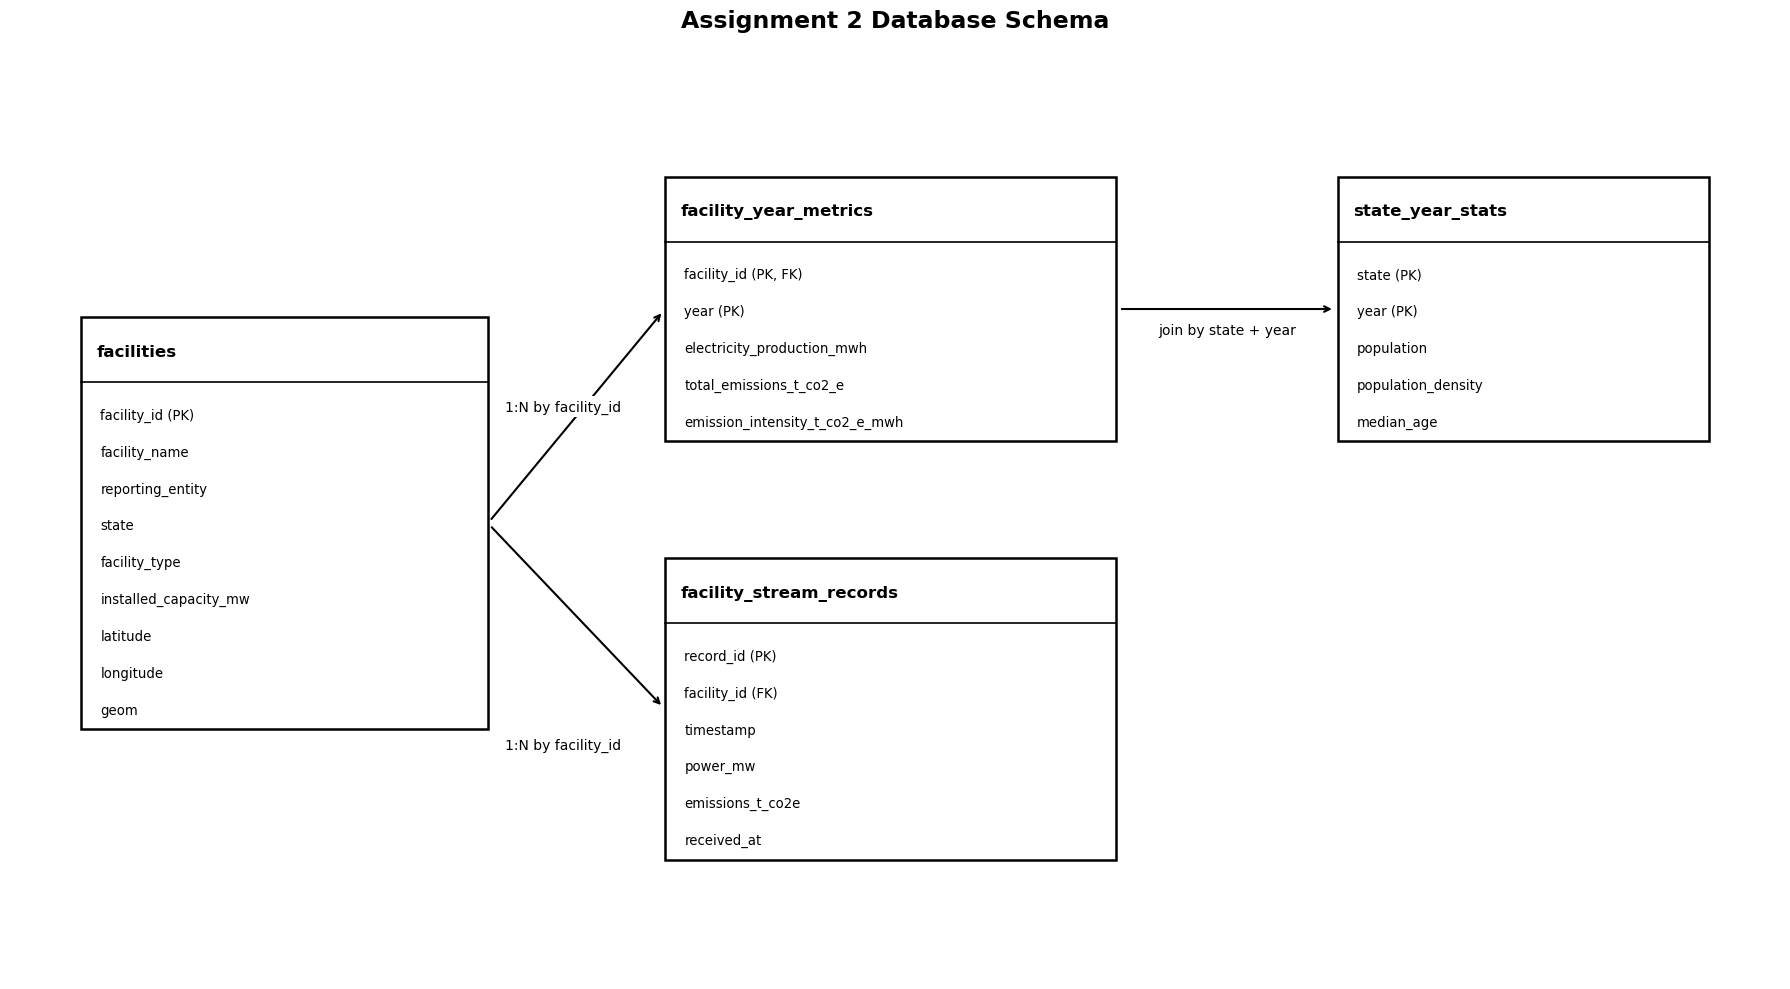

Schema diagram saved to: C:\Users\The_Won\Comp5339A2\output\figures\assignment2_database_schema.png


In [27]:
# Generate database schema diagram

schema_png_path = OUTPUT_DIR / "assignment2_database_schema.png"

fig, ax = plt.subplots(figsize=(18, 10))
ax.set_xlim(0, 20)
ax.set_ylim(0, 12)
ax.axis("off")


def draw_table(ax, x, y, width, title, fields, line_height=0.48):
    height = 1.05 + len(fields) * line_height

    rect = Rectangle(
        (x, y),
        width,
        height,
        fill=False,
        linewidth=1.8,
        edgecolor="black"
    )
    ax.add_patch(rect)

    header_y = y + height - 0.85
    ax.plot(
        [x, x + width],
        [header_y, header_y],
        linewidth=1.2,
        color="black"
    )

    ax.text(
        x + 0.18,
        y + height - 0.45,
        title,
        fontsize=12,
        fontweight="bold",
        va="center"
    )

    for i, field in enumerate(fields):
        ax.text(
            x + 0.22,
            y + height - 1.18 - i * line_height,
            field,
            fontsize=9.5,
            va="top"
        )

    return {
        "x": x,
        "y": y,
        "w": width,
        "h": height,
        "left": (x, y + height / 2),
        "right": (x + width, y + height / 2),
        "top": (x + width / 2, y + height),
        "bottom": (x + width / 2, y),
    }


facilities_box = draw_table(
    ax, 0.8, 3.25, 4.6, "facilities",
    [
        "facility_id (PK)",
        "facility_name",
        "reporting_entity",
        "state",
        "facility_type",
        "installed_capacity_mw",
        "latitude",
        "longitude",
        "geom"
    ]
)

annual_box = draw_table(
    ax, 7.4, 7.0, 5.1, "facility_year_metrics",
    [
        "facility_id (PK, FK)",
        "year (PK)",
        "electricity_production_mwh",
        "total_emissions_t_co2_e",
        "emission_intensity_t_co2_e_mwh"
    ]
)

stream_box = draw_table(
    ax, 7.4, 1.55, 5.1, "facility_stream_records",
    [
        "record_id (PK)",
        "facility_id (FK)",
        "timestamp",
        "power_mw",
        "emissions_t_co2e",
        "received_at"
    ]
)

state_box = draw_table(
    ax, 15.0, 7.0, 4.2, "state_year_stats",
    [
        "state (PK)",
        "year (PK)",
        "population",
        "population_density",
        "median_age"
    ]
)


# Relationship arrows
arrow_style = dict(
    arrowstyle="->",
    linewidth=1.5,
    shrinkA=4,
    shrinkB=4
)

ax.annotate(
    "",
    xy=annual_box["left"],
    xytext=facilities_box["right"],
    arrowprops=arrow_style
)

ax.text(
    6.25,
    7.45,
    "1:N by facility_id",
    fontsize=10,
    ha="center",
    va="center",
    bbox=dict(facecolor="white", edgecolor="none", pad=2.5)
)

ax.annotate(
    "",
    xy=stream_box["left"],
    xytext=facilities_box["right"],
    arrowprops=arrow_style
)

ax.text(
    6.25,
    3.05,
    "1:N by facility_id",
    fontsize=10,
    ha="center",
    va="center",
    bbox=dict(facecolor="white", edgecolor="none", pad=2.5)
)

ax.annotate(
    "",
    xy=state_box["left"],
    xytext=annual_box["right"],
    arrowprops=arrow_style
)

ax.text(
    13.75,
    8.45,
    "join by state + year",
    fontsize=10,
    ha="center",
    va="center",
    bbox=dict(facecolor="white", edgecolor="none", pad=2.5)
)

ax.set_title(
    "Assignment 2 Database Schema",
    fontsize=17,
    fontweight="bold",
    pad=22
)

plt.tight_layout()
plt.savefig(schema_png_path, dpi=300, bbox_inches="tight")
plt.show()

print("Schema diagram saved to:", schema_png_path)


In [28]:
summary = {
    "facilities_rows": con.execute("SELECT COUNT(*) FROM facilities").fetchone()[0],
    "annual_metric_rows": con.execute("SELECT COUNT(*) FROM facility_year_metrics").fetchone()[0],
    "state_year_rows": con.execute("SELECT COUNT(*) FROM state_year_stats").fetchone()[0],
    "stream_record_rows": con.execute("SELECT COUNT(*) FROM facility_stream_records").fetchone()[0],
    "stream_start": con.execute("SELECT MIN(timestamp) FROM facility_stream_records").fetchone()[0],
    "stream_end": con.execute("SELECT MAX(timestamp) FROM facility_stream_records").fetchone()[0],
    "unique_stream_facilities": con.execute("SELECT COUNT(DISTINCT facility_id) FROM facility_stream_records").fetchone()[0]
}

summary_df = pd.DataFrame([summary])
display(summary_df)


,facilities_rows,annual_metric_rows,state_year_rows,stream_record_rows,stream_start,stream_end,unique_stream_facilities
0,735,3215,48,354812,2026-05-01,2026-05-07 23:55:00,176


In [29]:
con.close()
print("DuckDB connection closed successfully.")


DuckDB connection closed successfully.
